# OBJECT LOCALIZATION USING YOLO CNN (Rectangle)

## IMPORT LIBRARIES

In [1]:
import numpy as np  # numerical operations
import cv2  # image processing
import matplotlib.pyplot as plt  # visualization
from sklearn.model_selection import train_test_split  # dataset split
from tensorflow.keras.callbacks import EarlyStopping  # early stopping

In [2]:
from tensorflow.keras.models import Sequential  # CNN model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense  # layers

## CONFIGURATION

In [3]:
Image_Size = 256  # input image size
sample = 1000

## DATASET

### CREATE

In [4]:
def create_dataset(samples=sample):

    images = []
    labels = []

    for _ in range(samples):

        img = np.zeros((Image_Size, Image_Size, 3),dtype=np.uint8)

        w = np.random.randint(20,50)
        h = np.random.randint(20,50)
        x = np.random.randint(5, Image_Size-w-5)
        y = np.random.randint(5, Image_Size-h-5)

        cv2.rectangle(img, (x, y), (x+w, y+h), (255,255,255), -1)

        x_center = (x + w/2) / Image_Size
        y_center = (y + h/2) / Image_Size
        width = w / Image_Size
        height = h / Image_Size

        labels.append([x_center, y_center, width, height])
        images.append(img)

    return np.array(images), np.array(labels)

### GENERATE

In [5]:
X, y = create_dataset(sample)

print("=" * 60)
print("DATASET CREATED")
print("=" * 60)

print("Images Shape :", X.shape)
print("Labels/Masks :", y.shape)

DATASET CREATED
Images Shape : (1000, 256, 256, 3)
Labels/Masks : (1000, 4)


### NORMALIZATION

In [6]:
X = X.astype("float32") / 255.0

### TRAIN TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)
print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

TRAIN / TEST SPLIT
Training Images : (800, 256, 256, 3)
Testing Images  : (200, 256, 256, 3)
Training Labels : (800, 4)
Testing Labels  : (200, 4)


## MODEL

### BUILD

In [8]:
model = Sequential([

    Input(shape=(Image_Size, Image_Size, 3)),  # input layer

    Conv2D(16, (3,3), padding="same", activation="relu"),  # feature extractor 1
    MaxPooling2D(),  # downsample

    Conv2D(16, (3,3), padding="same", activation="relu"),  # feature extractor 2
    MaxPooling2D(),  # downsample

    Conv2D(32, (3,3), padding="same", activation="relu"),  # feature extractor 3
    MaxPooling2D(),  # downsample

    Conv2D(64, (3,3), padding="same", activation="relu"),  # feature extractor 4
    MaxPooling2D(),  # downsample

    Conv2D(128, (3,3), padding="same", activation="relu"),  # feature extractor 5
    MaxPooling2D(),  # downsample

    Flatten(),  # flatten features

    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(4, activation="sigmoid")  # output bounding box
])

### SUMMARY

In [9]:
print("="*60)
print("MODEL SUMMARY")
print("="*60)

model.summary()

MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,230,580 (8.51 MB)

 Trainable params: 2,230,580 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

### COMPILE

In [10]:
model.compile(
    optimizer="adam",
    loss="mse"
)

### EARLY STOPPING

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",  # monitor validation loss
    patience=3,  # stop if no improvement
    restore_best_weights=True  # keep best model
)

### TRAIN

In [12]:
history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 0.0160 - val_loss: 0.0024
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.0015 - val_loss: 0.0012
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - loss: 8.7865e-04 - val_loss: 8.0902e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - loss: 7.0024e-04 - val_loss: 9.8289e-04
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 6.0229e-04 - val_loss: 5.7711e-04
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 4.6520e-04 - val_loss: 4.7786e-04
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 991ms/step - loss: 3.7458e-04 - val_loss: 4.3653e-04
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 2.7936e-04 - val_loss: 3.8307e-04
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 1.9976e-04 - val_loss: 2.8634e-04
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 1.3159e-04 - val_loss: 1.8081e-04
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 8.4802e-05 - val_loss: 1.4358e-04

## LOSS PLOT

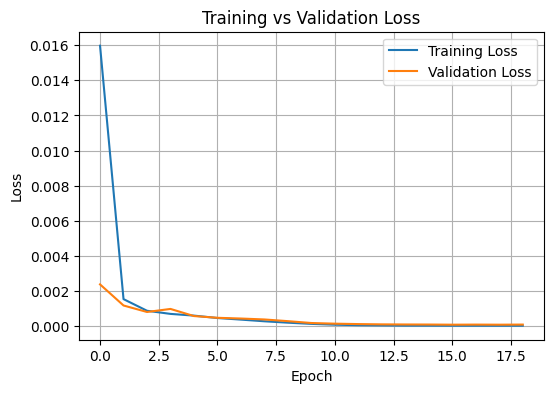

In [13]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label="Training Loss")  # training loss
plt.plot(history.history['val_loss'], label="Validation Loss")  # validation loss
plt.title("Training vs Validation Loss")  # title
plt.xlabel("Epoch")  # x-axis
plt.ylabel("Loss")  # y-axis
plt.title("Training vs Validation Loss")
plt.legend()  # legend
plt.grid(True)
plt.show()  # display graph

## IoU FUNCTION

In [14]:
def IoU(box1, box2):

    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min = x1 - w1 / 2
    x1_max = x1 + w1 / 2
    y1_min = y1 - h1 / 2
    y1_max = y1 + h1 / 2

    x2_min = x2 - w2 / 2
    x2_max = x2 + w2 / 2
    y2_min = y2 - h2 / 2
    y2_max = y2 + h2 / 2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_area = max(0,inter_xmax - inter_xmin) * max(0,inter_ymax - inter_ymin)
    union = (w1*h1) + (w2*h2) - inter_area

    return inter_area / (union + 1e-6)

## VISUALIZATION (TRUE VS PREDICTED)

In [15]:
def draw_box(img, box, color):

    x, y, w, h = box

    x *= Image_Size
    y *= Image_Size
    w *= Image_Size
    h *= Image_Size

    x1 = int(x - w/2)
    y1 = int(y - h/2)
    x2 = int(x + w/2)
    y2 = int(y + h/2)

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

In [16]:
preds = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step


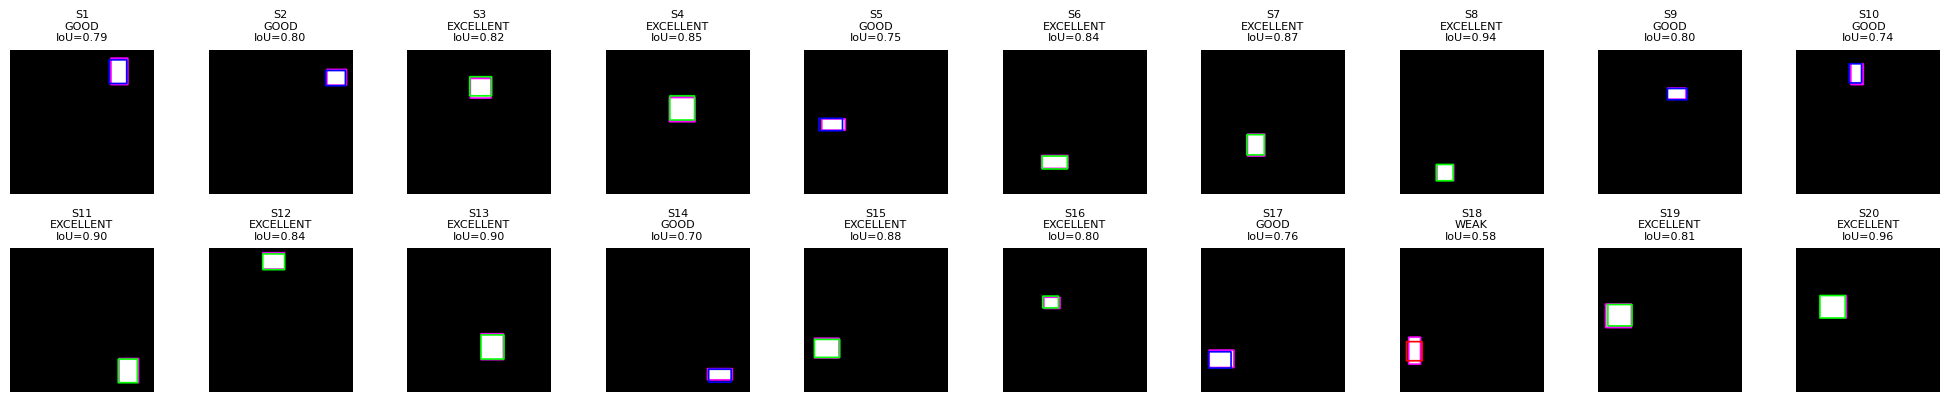

In [17]:
plt.figure(figsize=(20,20))

for i in range(min(len(X_test),20)):

    img = (X_test[i] * 255).astype(np.uint8).copy()

    # Yolo
    iou = IoU(preds[i], y_test[i])
    draw_box(img, y_test[i], (255,0,255))

    if iou >= 0.80:
        pred_color = (0,255,0)
        status = "EXCELLENT"
    elif iou >= 0.60:
        pred_color = (255,0,0)
        status = "GOOD"
    else:
        pred_color = (0,0,255)
        status = "WEAK"

    # Yolo
    draw_box(img, preds[i], pred_color)

    plt.subplot(10,10,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"S{i+1}\n{status}\nIoU={iou:.2f}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## REPORT

In [18]:
ious = []

In [19]:
for i in range(len(preds)):
    ious.append(IoU(preds[i], y_test[i]))

In [20]:
excellent = 0
good = 0
weak = 0

for iou in ious:
    if iou >= 0.80:
        excellent += 1
    elif iou >= 0.60:
        good += 1
    else:
        weak += 1

print("="*80)

# Yolo
print("LOCALIZATION REPORT")

print("="*80)

for i in range(len(preds)):
    iou = ious[i]
    if iou >= 0.80:
        status = "✔ EXCELLENT"
    elif iou >= 0.60:
        status = "➜ GOOD"
    else:
        status = "✖ WEAK"
    print(f"\nSample {i+1}")
    print("-"*60)

    # Yolo
    print("True Box      :", np.round(y_test[i],3))
    print("Predicted Box :", np.round(preds[i],3))

    print("IoU :", round(iou,3))
    print("Status :", status)

LOCALIZATION REPORT

Sample 1
------------------------------------------------------------
True Box      : [0.758 0.146 0.117 0.184]
Predicted Box : [0.749 0.151 0.124 0.166]
IoU : 0.793
Status : ➜ GOOD

Sample 2
------------------------------------------------------------
True Box      : [0.885 0.188 0.137 0.109]
Predicted Box : [0.879 0.196 0.137 0.108]
IoU : 0.797
Status : ➜ GOOD

Sample 3
------------------------------------------------------------
True Box      : [0.51  0.264 0.145 0.137]
Predicted Box : [0.512 0.253 0.151 0.134]
IoU : 0.821
Status : ✔ EXCELLENT

Sample 4
------------------------------------------------------------
True Box      : [0.527 0.412 0.18  0.168]
Predicted Box : [0.53  0.403 0.171 0.166]
IoU : 0.853
Status : ✔ EXCELLENT

Sample 5
------------------------------------------------------------
True Box      : [0.203 0.516 0.164 0.078]
Predicted Box : [0.186 0.516 0.166 0.085]
IoU : 0.75
Status : ➜ GOOD

Sample 6
----------------------------------------------

In [21]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print("Total Samples :", len(ious))
print(f"Excellent (>=0.80) : {excellent} -> {(excellent/len(ious))*100:.2f}%")
print(f"Good (>=0.60) : {good} -> {(good/len(ious))*100:.2f}%")
print(f"Weak (<0.60) : {weak} -> {(weak/len(ious))*100:.2f}%")
print("Average IoU :", round(np.mean(ious),3))

FINAL SUMMARY
Total Samples : 200
Excellent (>=0.80) : 134 -> 67.00%
Good (>=0.60) : 63 -> 31.50%
Weak (<0.60) : 3 -> 1.50%
Average IoU : 0.819
